In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import gdown
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import pandas as pd
from tqdm import tqdm

In [4]:
# Google Drive file ID for gender model
GENDER_MODEL_ID = "1FqdiDojonhUa_NcZiVAED8_boEY7Qq3z"

In [5]:
# Image parameters
IMG_SIZE = (224, 224)  # For gender classification

In [6]:
class ModelDownloader:
    """Download gender model from Google Drive"""

    @staticmethod
    def download_file(file_id, output_path):
        """Download file from Google Drive using file ID"""
        url = f"https://drive.google.com/uc?id={file_id}"
        try:
            gdown.download(url, output_path, quiet=False)
            print(f"Downloaded: {output_path}")
            return True
        except Exception as e:
            print(f"Error downloading {output_path}: {e}")
            return False

    @staticmethod
    def download_gender_model():
        """Download gender classification model"""
        return ModelDownloader.download_file(GENDER_MODEL_ID, "gender_model.keras")


In [7]:
class GenderClassifier:
    """Gender classification model wrapper"""

    def __init__(self, model_path="gender_model.keras"):
        self.model = None
        self.model_path = model_path
        self.load_model()

    def load_model(self):
        """Load the gender classification model"""
        try:
            self.model = tf.keras.models.load_model(self.model_path)
            print("Gender classification model loaded successfully.")
        except Exception as e:
            print(f"Error loading gender model: {e}")

    def preprocess_image(self, img_path):
        """Preprocess image for gender classification"""
        img = cv2.imread(img_path)
        if img is None:
            raise ValueError(f"Could not load image at {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        img = img / 255.0
        img = np.expand_dims(img, axis=0)
        return img

    def predict(self, img_path):
        """Predict gender for a single image"""
        if self.model is None:
            raise ValueError("Model not loaded")

        img = self.preprocess_image(img_path)
        prediction = self.model.predict(img, verbose=0)[0][0]
        label = 'male' if prediction > 0.5 else 'female'
        confidence = prediction if prediction > 0.5 else 1 - prediction

        return label, confidence

In [8]:
class GenderEvaluator:
    """Evaluation and visualization utilities for gender classification"""

    @staticmethod
    def evaluate_gender_classification(gender_classifier, test_folder_path):
        """Evaluate gender classification model"""
        results = {'predictions': [], 'true_labels': [], 'confidences': [], 'image_paths': []}

        for gender in ['female', 'male']:
            gender_folder = os.path.join(test_folder_path, gender)
            if not os.path.exists(gender_folder):
                print(f"Warning: {gender_folder} does not exist")
                continue

            image_files = [f for f in os.listdir(gender_folder)
                          if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff'))]

            print(f"Processing {len(image_files)} images in {gender} folder...")

            for img_file in tqdm(image_files, desc=f"Processing {gender}"):
                img_path = os.path.join(gender_folder, img_file)
                try:
                    predicted_label, confidence = gender_classifier.predict(img_path)
                    results['predictions'].append(predicted_label)
                    results['true_labels'].append(gender)
                    results['confidences'].append(confidence)
                    results['image_paths'].append(img_path)
                except Exception as e:
                    print(f"Error processing {img_path}: {e}")

        return results

    @staticmethod
    def calculate_metrics(y_true, y_pred):
        """Calculate classification metrics"""
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1
        }

    @staticmethod
    def plot_results(results):
        """Plot gender classification results"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # Confusion Matrix
        cm = confusion_matrix(results['true_labels'], results['predictions'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'],
                   ax=axes[0, 0])
        axes[0, 0].set_title('Confusion Matrix')
        axes[0, 0].set_xlabel('Predicted')
        axes[0, 0].set_ylabel('True')

        # Accuracy by class
        df = pd.DataFrame({
            'true_labels': results['true_labels'],
            'predictions': results['predictions']
        })
        accuracy_by_class = df.groupby('true_labels').apply(
            lambda x: (x['true_labels'] == x['predictions']).mean()
        )
        accuracy_by_class.plot(kind='bar', ax=axes[0, 1])
        axes[0, 1].set_title('Accuracy by Gender')
        axes[0, 1].set_xlabel('Gender')
        axes[0, 1].set_ylabel('Accuracy')
        axes[0, 1].tick_params(axis='x', rotation=0)

        # Confidence distribution
        axes[1, 0].hist(results['confidences'], bins=20, alpha=0.7, edgecolor='black')
        axes[1, 0].set_title('Confidence Distribution')
        axes[1, 0].set_xlabel('Confidence')
        axes[1, 0].set_ylabel('Frequency')

        # Metrics bar plot
        metrics = GenderEvaluator.calculate_metrics(results['true_labels'], results['predictions'])
        metric_names = list(metrics.keys())
        metric_values = list(metrics.values())

        bars = axes[1, 1].bar(metric_names, metric_values, color=['skyblue', 'orange', 'green', 'red'])
        axes[1, 1].set_title('Performance Metrics')
        axes[1, 1].set_ylabel('Score')
        axes[1, 1].set_ylim(0, 1)

        for bar, value in zip(bars, metric_values):
            axes[1, 1].text(bar.get_x() + bar.get_width()/2, value + 0.02,
                           f'{value:.3f}', ha='center')

        plt.tight_layout()
        plt.savefig('gender_classification_results.png', dpi=300, bbox_inches='tight')
        plt.show()

        return metrics

    @staticmethod
    def show_sample_predictions(results, num_samples=10):
        """Show sample predictions with images"""
        indices = np.random.choice(len(results['image_paths']),
                                 min(num_samples, len(results['image_paths'])),
                                 replace=False)

        cols = 5
        rows = (len(indices) + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
        if rows == 1:
            axes = [axes] if cols == 1 else axes
        else:
            axes = axes.flatten()

        for i, idx in enumerate(indices):
            if i >= len(axes):
                break

            img_path = results['image_paths'][idx]
            true_label = results['true_labels'][idx]
            pred_label = results['predictions'][idx]
            confidence = results['confidences'][idx]

            # Load and display image
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            axes[i].imshow(img)
            axes[i].axis('off')

            # Color code: green for correct, red for incorrect
            color = 'green' if true_label == pred_label else 'red'
            title = f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}"
            axes[i].set_title(title, color=color, fontsize=10)

        # Hide unused subplots
        for i in range(len(indices), len(axes)):
            axes[i].axis('off')

        plt.tight_layout()
        plt.savefig('sample_gender_predictions.png', dpi=300, bbox_inches='tight')
        plt.show()

In [9]:
def Test():
    """Test function for gender classification evaluation"""
    print("="*60)
    print("TASK A - GENDER CLASSIFICATION EVALUATION")
    print("="*60)

    # Download model
    print("Downloading gender classification model from Google Drive...")
    if not ModelDownloader.download_gender_model():
        print("Failed to download gender model. Please check your file ID.")
        return

    # Initialize model
    print("\nInitializing gender classification model...")
    gender_classifier = GenderClassifier()

    if gender_classifier.model is None:
        print("Failed to load gender classification model.")
        return

    # Get test folder path from user
    task_a_path = "Update the path"

    # Validate path
    if not os.path.exists(task_a_path):
        print(f"Path does not exist: {task_a_path}")
        return

    # Check if required folders exist
    female_folder = os.path.join(task_a_path, 'female')
    male_folder = os.path.join(task_a_path, 'male')

    if not os.path.exists(female_folder):
        print(f"Female folder not found: {female_folder}")
        return

    if not os.path.exists(male_folder):
        print(f"Male folder not found: {male_folder}")
        return

    # Evaluate gender classification
    print("\nEvaluating gender classification...")
    gender_results = GenderEvaluator.evaluate_gender_classification(gender_classifier, task_a_path)

    if not gender_results['predictions']:
        print("No predictions were made. Please check your test images.")
        return

    # Calculate and print metrics
    gender_metrics = GenderEvaluator.calculate_metrics(
        gender_results['true_labels'],
        gender_results['predictions']
    )

    print("\n" + "="*50)
    print("GENDER CLASSIFICATION RESULTS")
    print("="*50)
    print(f"Total images processed: {len(gender_results['predictions'])}")
    print(f"Accuracy: {gender_metrics['accuracy']:.4f}")
    print(f"Precision: {gender_metrics['precision']:.4f}")
    print(f"Recall: {gender_metrics['recall']:.4f}")
    print(f"F1-Score: {gender_metrics['f1_score']:.4f}")

    # Print classification report
    print("\nDetailed Classification Report:")
    print(classification_report(gender_results['true_labels'],
                              gender_results['predictions']))

    # Plot results
    print("\nGenerating visualization plots...")
    GenderEvaluator.plot_results(gender_results)
    GenderEvaluator.show_sample_predictions(gender_results, num_samples=10)

    # Save results to CSV
    results_df = pd.DataFrame({
        'image_path': gender_results['image_paths'],
        'true_label': gender_results['true_labels'],
        'predicted_label': gender_results['predictions'],
        'confidence': gender_results['confidences']
    })
    results_df.to_csv('gender_classification_results.csv', index=False)
    print("\nResults saved to 'gender_classification_results.csv'")

    print("\nGender classification evaluation completed!")
    print("Check the saved plots and CSV file for detailed results.")


TASK A - GENDER CLASSIFICATION EVALUATION


Downloading...
From: https://drive.google.com/uc?id=1FqdiDojonhUa_NcZiVAED8_boEY7Qq3z
To: /content/gender_model.keras
100%|██████████| 11.6M/11.6M [00:00<00:00, 137MB/s]


Downloaded: gender_model.keras

Initializing gender classification model...


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Gender classification model loaded successfully.
Enter the path to Task A folder (containing 'female' and 'male' folders): /content/Task A

Evaluating gender classification...
Processing 79 images in female folder...


Processing female: 100%|██████████| 79/79 [00:14<00:00,  5.49it/s]


Processing 343 images in male folder...


Processing male: 100%|██████████| 343/343 [01:03<00:00,  5.37it/s]



GENDER CLASSIFICATION RESULTS
Total images processed: 422
Accuracy: 0.8839
Precision: 0.9147
Recall: 0.8839
F1-Score: 0.8916

Detailed Classification Report:
              precision    recall  f1-score   support

      female       0.63      0.92      0.75        79
        male       0.98      0.87      0.92       343

    accuracy                           0.88       422
   macro avg       0.80      0.90      0.84       422
weighted avg       0.91      0.88      0.89       422


Generating visualization plots...


/tmp/ipython-input-8-478263482.py:67: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  accuracy_by_class = df.groupby('true_labels').apply(


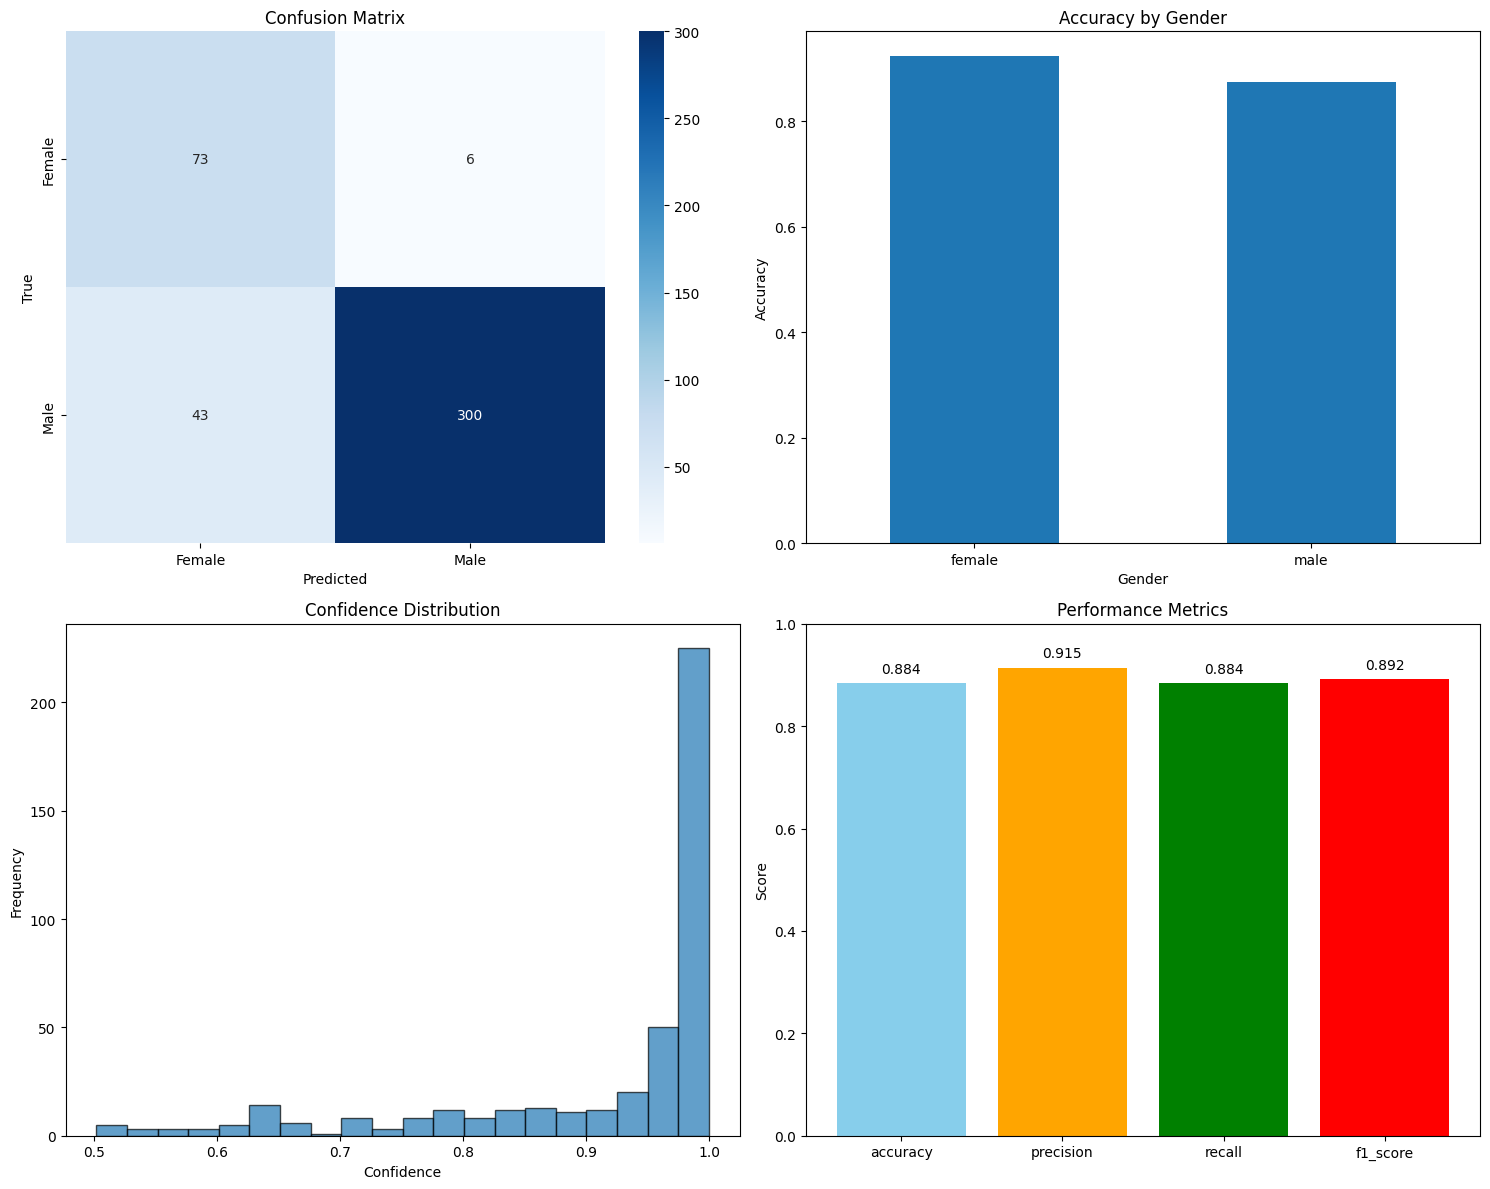

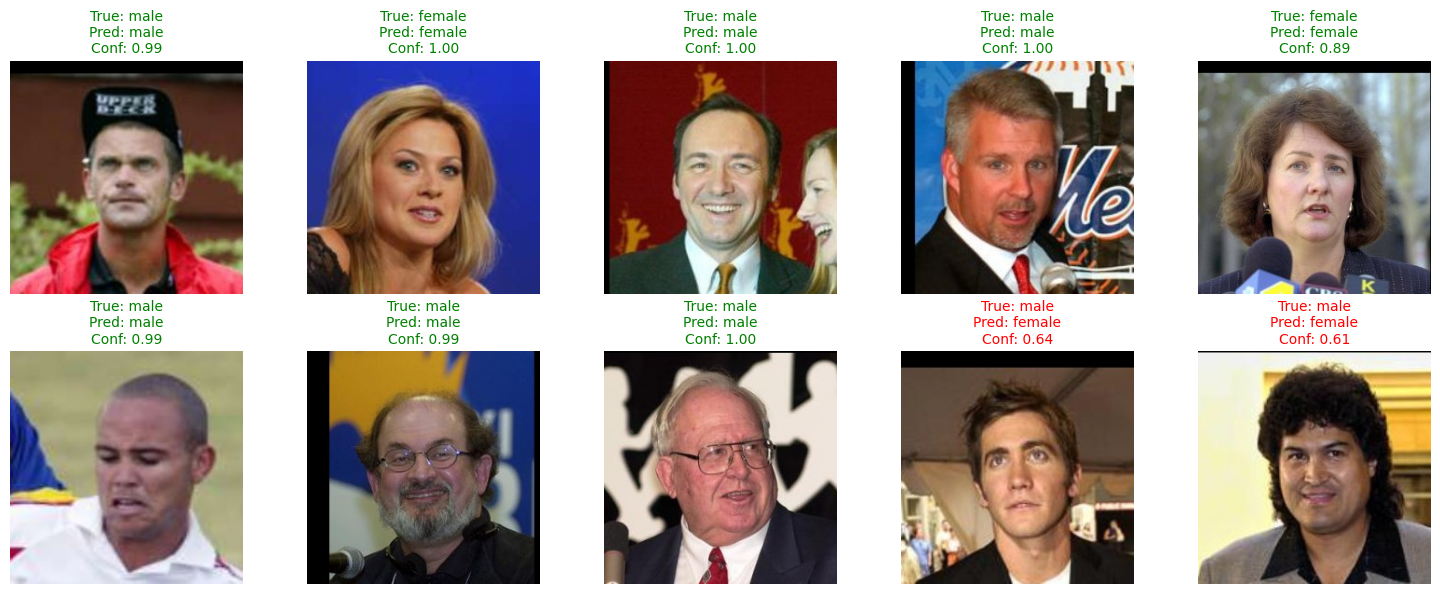


Results saved to 'gender_classification_results.csv'

Gender classification evaluation completed!
Check the saved plots and CSV file for detailed results.


In [11]:
Test()